## 0. Computer vision libraries in PyTorch
* `torchvision`: base domain library for PyTorch vision
* `torchvision.datasets`: get datasets and data laoding functions for computer vision here
* `torchvision.models`: get pretrained computer vision models
* `torchvision.transforms`: functions for manipulating images for a ML algo
* `torch.utils.data.Dataset`: Base dataset class for PyTorch
* `torch.utils.data.DataLoader`: Creates a python iterable over the data

In [193]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu124
0.20.1+cu124


## 1. Getting the dataset
We'll be using the Fashion MNIST dataset

In [194]:
# Setup training data
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download= True,
    transform= torchvision.transforms.ToTensor(), # how do we want to transfromt the data?
    target_transform= None # how to transform the labels?
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download= True,
    transform= torchvision.transforms.ToTensor(), # how do we want to transfromt the data?
    target_transform= None # how to transform the labels?
)

In [195]:
len(train_data)

60000

In [196]:
len(test_data)

10000

In [197]:
# See the first training example
image, label = train_data[0]
print(image.shape, label)

torch.Size([1, 28, 28]) 9


In [198]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [199]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [200]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

Grayscale images have 1 color channer


Coloured channels have 3 color channels

### 1.2 Visualizing the data

Image shape: torch.Size([1, 28, 28])


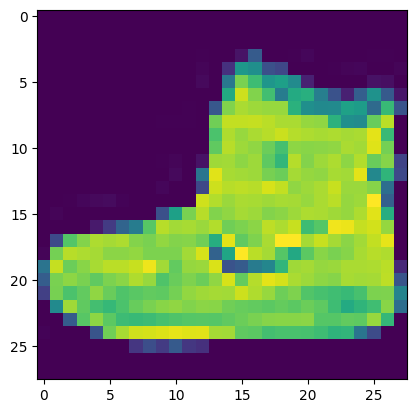

In [201]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()); # matplotlib expects height, widht, color channels. the data we have is color channel, height, width. so we squeeze to remove the extra dimension with value 1 (i.e. the color channel =1 for a gray scale image)

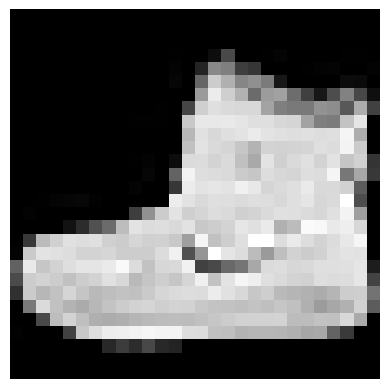

In [202]:
plt.imshow(image.squeeze(), cmap = "gray");
plt.axis(False);

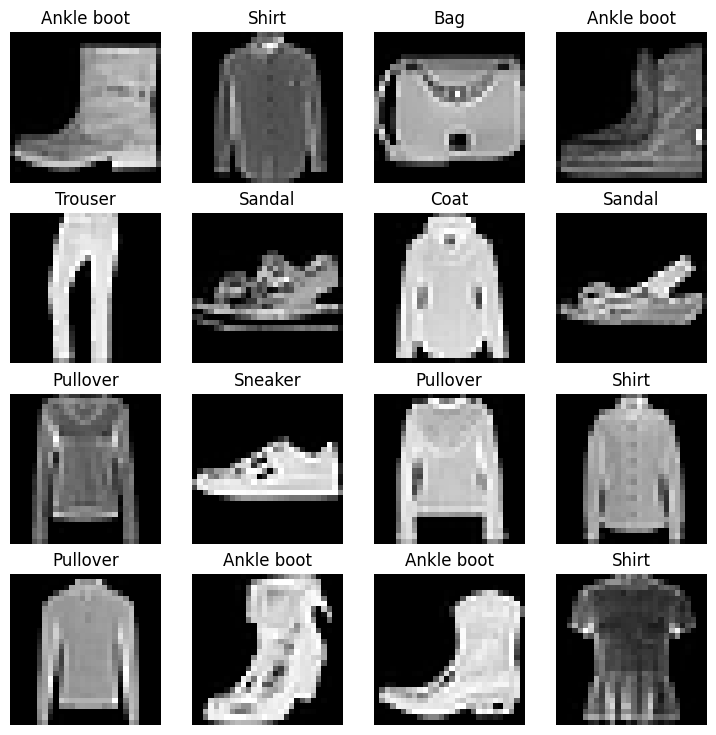

In [203]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):  # Fix 'clos' to 'cols'
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")  # Ensure correct shape
    plt.title(class_names[label])
    plt.axis("off")  # Change False to "off"

plt.show()

## 2. Prepare DataLoader

DataLoader converts the dataset into Python iterable. Furthermore, we are looking to create batches/ mini-batches of the data

In [204]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    shuffle = False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c522d151410>,
 <torch.utils.data.dataloader.DataLoader at 0x7c522d42af90>)

In [205]:
len(train_dataloader), len(test_dataloader)

(1875, 313)

We have 313 batches, with each batch having 32 images

In [206]:
# Check out what is in the Dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28])
Label: 6, Label shape : torch.Size([])


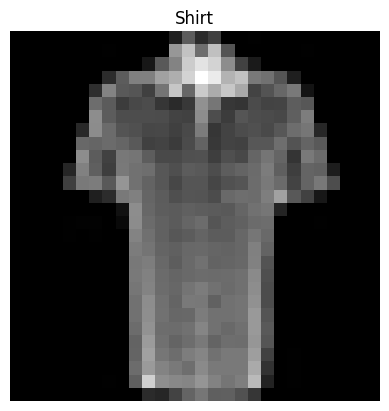

In [207]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False);
print(f"Image shape: {img.shape}")
print(f"Label: {label}, Label shape : {label.shape}")

## 3. Model 0: Build a baseline model

In [208]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

x.shape # shape before flattening

torch.Size([1, 28, 28])

In [209]:
# Flatten the sample
output = flatten_model(x) # perform forward pass
output.shape # shape after flattening

torch.Size([1, 784])

In [210]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape, out_features= hidden_units),
        nn.Linear(in_features= hidden_units, out_features= output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [211]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape= 784, # this is 28 * 28
    hidden_units= 10,
    output_shape= len(class_names)
).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [212]:
dummy_x = torch.rand([1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

### 3.1 Set up loss, optimizer and evaluation metrics

* Since we are working with multi-class data, our loss function will be: `nn.CrossEntropy()`
* Optimzier: `torch.optim.SGD()`
* Evaluation metric: Accuracy

In [213]:
import requests
from pathlib import Path

# Downlaod the helper functions
if not Path("helper_functions.py").is_file():
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open ("helper_functions.py", "wb") as f:
    f.write(request.content)

In [214]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1)

### 3.2 Creating a functions to time our experiments

There are two things which practitioners are always looking to track:
1. Model's performance
2. Training Speed

In [215]:
from timeit import default_timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """
  Prints difference between the start and the end time
  """
  total_time = end -start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs
2. Loop through training batches, perform training steps, calculate the train loss per batch
3. Do the same for testing loop
4. Print out the info about process
5. Time the process

In [216]:
from timeit import default_timer as timer

# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per epoch

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 32.321 seconds


In [217]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 4. Make predictions and get model results

In [218]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_laoder: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """
  Returns a dictionary containing the results of model prediction on data_loader
  """
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_laoder):
      X, y = X.to(device), y.to(device)
      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim =1))

    # Scale loss and acc to find the average loss and accuracy
    loss /= len(data_laoder)
    acc /= len(data_laoder)

    return {"model_name": model.__class__.__name__, # works only when the model is created with a class
            "model_loss": loss.item(),
            "model_acc": acc
            }

# Calculate model 0 results on the test dataset
model_0_results = eval_model(model = model_0,
                             data_laoder= test_dataloader,
                             loss_fn= loss_fn,
                             accuracy_fn= accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 5. Setup device agnostic-code

In [219]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [220]:
torch.cuda.is_available()

False

In [221]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 6. Model 1: Building a better model with non-linearity

In [222]:
import torch
import torch.nn as nn

# Create a model with linear and non-linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),  # Corrected from ReLu() to ReLU()
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            nn.ReLU()  # Corrected from ReLu() to ReLU()
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [223]:
next(model_0.parameters()).device

device(type='cpu')

In [224]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape =  784, # this is the output of FLatten layer when the image is sent in with dimensions of 28*28
                              hidden_units= 10,
                              output_shape= len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cpu')

In [225]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss() # measures how wrong is our model
optimizer = torch.optim.SGD(params= model_1.parameters(),
                            lr= 0.1) # tries to update the model's parameter to reduce the loss

### 6.2 Functionising training and evaluation/testing loops

Let's create a function for:
1. Training loop- `train_step()`
2. Testing loop- `test_step()`

In [226]:
def train_step(model :torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc =0, 0

  # Put model into training mode
  model.train()

  # Add a loop to loop through training batches
  for batch, (X, y) in enumerate(data_loader):
      # Put the data on the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate loss and accuracy (per batch)
      loss = loss_fn(y_pred, y)
      train_loss += loss # accumulatively add up the loss per epoch
      train_acc += accuracy_fn(y_true=y, y_pred = y_pred.argmax(dim= 1))

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

  # Divide total train loss by length of train dataloader (average loss per batch per epoch)
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}")

In [227]:
import torch
import torch.nn as nn

def test_step(model: nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device,
              accuracy_fn):
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0.0, 0.0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            # Move data to the appropriate device
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            # Calculate and accumulate loss
            test_loss += loss_fn(test_pred, y).item()  # Use .item() to get a scalar value

            # Calculate and accumulate accuracy
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    # Compute average loss and accuracy
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    ## Print out what's happening
    print(f"\nTest loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

In [228]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start = timer()

# Set epochs
epochs =3

# Create a optimization and evaluation loop using train_step() and test_loop()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----------------------------")
  train_step(model = model_1,
             data_loader= train_dataloader,
             loss_fn = loss_fn,
             accuracy_fn = accuracy_fn,
             optimizer = optimizer,
             device = device)
  test_step(model = model_1,
            data_loader=test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device =device)

train_time_end = timer()
total_train_time_model_1 = print_train_time(start = train_time_start,
                                            end = train_time_end,
                                            device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----------------------------
Train Loss: 1.09 | Train Accuracy: 61.34

Test loss: 0.95637, Test acc: 65.00%

Epoch: 1
-----------------------------
Train Loss: 0.78 | Train Accuracy: 71.93

Test loss: 0.72227, Test acc: 73.91%

Epoch: 2
-----------------------------
Train Loss: 0.67 | Train Accuracy: 75.94

Test loss: 0.68500, Test acc: 75.02%

Train time on cpu: 33.229 seconds


In [229]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [230]:
total_train_time_model_0

32.320899984999414

In [231]:
# Get model_1 results dictionary
model_1_results = eval_model(model = model_1,
                             data_laoder = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn= accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850009560585022,
 'model_acc': 75.01996805111821}

In [232]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## Model 2: Building a CNN

In [233]:


# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

# when making the model, just make the model without thinking of the shapes. then, pass dummy data through the layer. see what is the expected shape and all and you get what shape should your input should be. herein, we were concerned about the in_features for the linear layer in self.classififer

In [234]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape= 1, # the input shape herein refers to the numer of channels we have. Since we are working with black and white images, we have one colour channel. In case we are working with colourful images, then we have to keep this value as 3
                              hidden_units= 10,
                              output_shape= len(class_names)
                              ).to(device)

## 7.1 Stepping through `nn.Conv2d`

In [235]:
torch.manual_seed(42)

# Create a batch of images
images= torch.randn(size = (32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test Image: \n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test Image: 
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [236]:
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels=10,
                       kernel_size = 3,
                       stride = 1,
                       padding =0)
# Pass the data through convolutional layer
conv_output = conv_layer((test_image.unsqueeze(dim =0)))
conv_output

tensor([[[[-2.8778e-01, -6.0596e-02, -5.6306e-02,  ...,  2.8654e-01,
            6.6224e-01, -2.3216e-01],
          [-9.8911e-01, -4.0099e-01,  4.1832e-01,  ...,  4.7459e-01,
           -1.8552e-01, -5.7622e-01],
          [-4.1340e-02, -2.3277e-01,  3.7418e-01,  ...,  2.8255e-02,
            1.4923e-01,  1.4236e-01],
          ...,
          [-8.0374e-01, -7.6687e-01, -5.9457e-02,  ...,  1.7452e-01,
            4.2594e-01, -4.8341e-01],
          [-1.4512e-01, -1.1566e-01,  6.1783e-01,  ...,  2.4126e-01,
           -3.6626e-01,  3.5645e-01],
          [ 3.6096e-02,  1.5214e-01,  2.3123e-01,  ...,  3.0904e-01,
           -4.9680e-01, -7.2258e-01]],

         [[-1.0853e+00, -1.6079e+00,  1.3346e-01,  ...,  2.1698e-01,
           -1.7643e+00,  2.5263e-01],
          [-8.2507e-01,  6.3866e-01,  1.8845e-01,  ..., -1.0936e-01,
            4.8068e-01,  8.4869e-01],
          [ 6.4927e-01, -4.2061e-03, -4.9991e-01,  ...,  5.8356e-01,
            2.4611e-01,  6.6233e-01],
          ...,
     

In [237]:
test_image.unsqueeze(dim =0).shape

torch.Size([1, 3, 64, 64])

In [238]:
conv_output.shape

torch.Size([1, 10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [239]:
test_image.shape

torch.Size([3, 64, 64])

In [240]:
# Print out original image shape without unsqueeze dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# Create a sample MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size = 2)

# PAss data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim = 0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through max pool layer
test_image_through_conv_and_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through the conv_layer and max_pool layer: {test_image_through_conv_and_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through the conv_layer and max_pool layer: torch.Size([1, 10, 31, 31])


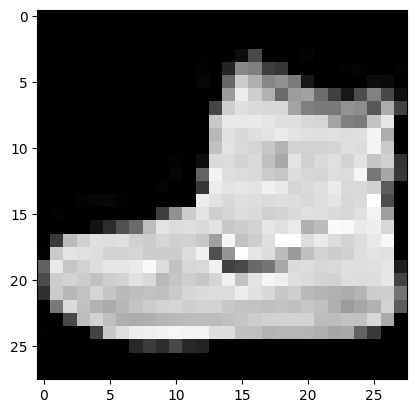

In [241]:
plt.imshow(image.squeeze(), cmap = "gray")

In [242]:
random_image_tensor = torch.rand(size = (1, 28, 28))
random_image_tensor.shape

torch.Size([1, 28, 28])

In [243]:
# Pass the random iamge with the same dimension as our data into the model
model_2(random_image_tensor.unsqueeze(dim = 0).to(device))

tensor([[ 0.0342, -0.0697,  0.0616, -0.0407, -0.0062,  0.0199, -0.0023, -0.0113,
          0.0178,  0.0016]], grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss function and optimizer for `model_2`

In [244]:
# Setup loss functions and optimizers
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(), lr = 0.1)

In [245]:
model_2.state_dict() # gives the parameters of the model

OrderedDict([('block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
           

### 7.4 Training and testing `model_2` using our training and testing functions

In [246]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test the model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------------------------------")
  train_step(model = model_2,
             data_loader= train_dataloader,
             loss_fn= loss_fn,
             optimizer= optimizer,
             accuracy_fn= accuracy_fn,
             device = device)
  test_step(model= model_2,
            data_loader= test_dataloader,
            loss_fn= loss_fn,
            device = device,
            accuracy_fn= accuracy_fn)
train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start = train_time_start_model_2,
                                            end= train_time_end_model_2,
                                            device =device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------------------------------
Train Loss: 0.60 | Train Accuracy: 78.38

Test loss: 0.39500, Test acc: 85.99%

Epoch: 1
-------------------------------
Train Loss: 0.37 | Train Accuracy: 86.90

Test loss: 0.35244, Test acc: 86.91%

Epoch: 2
-------------------------------
Train Loss: 0.33 | Train Accuracy: 88.13

Test loss: 0.32719, Test acc: 88.07%

Train time on cpu: 182.703 seconds


In [247]:
# Get model_2 results dictionary
mdoel_2_results = eval_model(model = model_2,
                             data_laoder= test_dataloader,
                             loss_fn= loss_fn,
                             accuracy_fn= accuracy_fn)
mdoel_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [248]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [249]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850009560585022,
 'model_acc': 75.01996805111821}

### 8. Comparing model results and training time

In [250]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                mdoel_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.327190,88.069089


In [251]:
# Add training time to results comparison
compare_results["model_training_time"] = [total_train_time_model_0,
                                          total_train_time_model_1,
                                          total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,model_training_time
0,FashionMNISTModelV0,0.476639,83.426518,32.320900
1,FashionMNISTModelV1,0.685001,75.019968,33.229037
2,FashionMNISTModelV2,0.327190,88.069089,182.703224


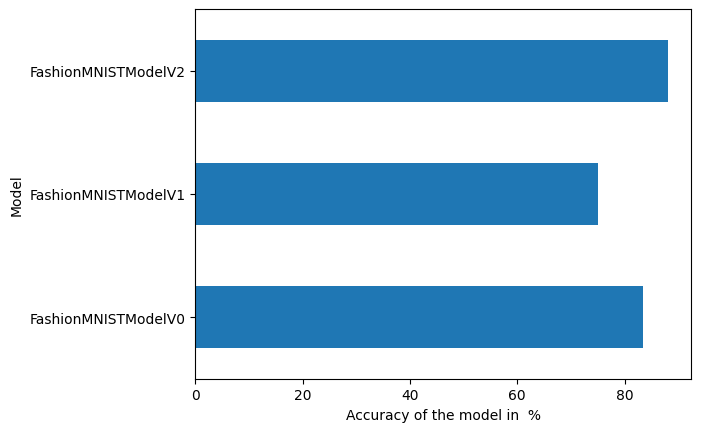

In [252]:
#Visualise our model results
compare_results.set_index("model_name")["model_acc"].plot(kind = "barh")
plt.xlabel("Accuracy of the model in  %")
plt.ylabel("Model");

## 9. Make and evaluate random predictions with best model

In [253]:
def make_predictions(model: nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add batch size dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim =0).to(device)

      # Forward pass (modle gives raw logits)
      pred_logit = model(sample)

      # Get prediction probabilittes from the raw logits
      pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)

      # Get pred_prob on CPU as matplotlib works only on the CPU
      pred_probs.append(pred_prob.cpu())
  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [254]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

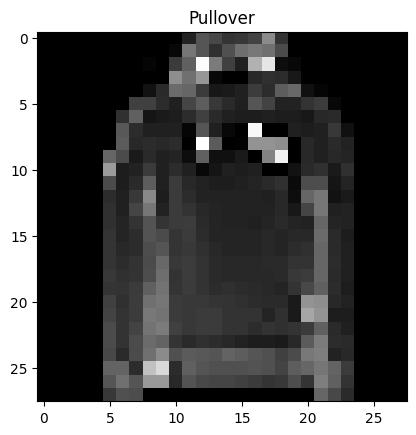

In [255]:
plt.imshow(test_samples[0].squeeze(), cmap = "gray")
plt.title(class_names[test_labels[0]]);

In [256]:
# Make predictions
pred_probs = make_predictions(model = model_2,
                              data = test_samples)

# View first two prediction probabilities
pred_probs[:2]

tensor([[4.9888e-02, 1.8706e-03, 5.7892e-01, 9.2597e-03, 1.9227e-01, 9.2515e-05,
         1.4721e-01, 1.8579e-04, 2.0143e-02, 1.5928e-04],
        [4.4751e-04, 5.4043e-05, 6.0747e-02, 4.6409e-04, 9.3198e-01, 6.9176e-07,
         3.2903e-03, 7.9197e-06, 2.9982e-03, 8.0210e-06]])

In [257]:
test_labels

[2, 4, 6, 3, 2, 2, 0, 1, 1]

In [258]:
# Convert prediction probabilites to labels
pred_classes = pred_probs.argmax(dim = 1)

In [259]:
pred_classes

tensor([2, 4, 6, 3, 2, 2, 0, 1, 1])

To clear the confusion about dim = 0 and dim =1, I used this: https://discuss.pytorch.org/t/whats-different-between-dim-1-and-dim-0/61094/2

In [260]:
test_labels

[2, 4, 6, 3, 2, 2, 0, 1, 1]

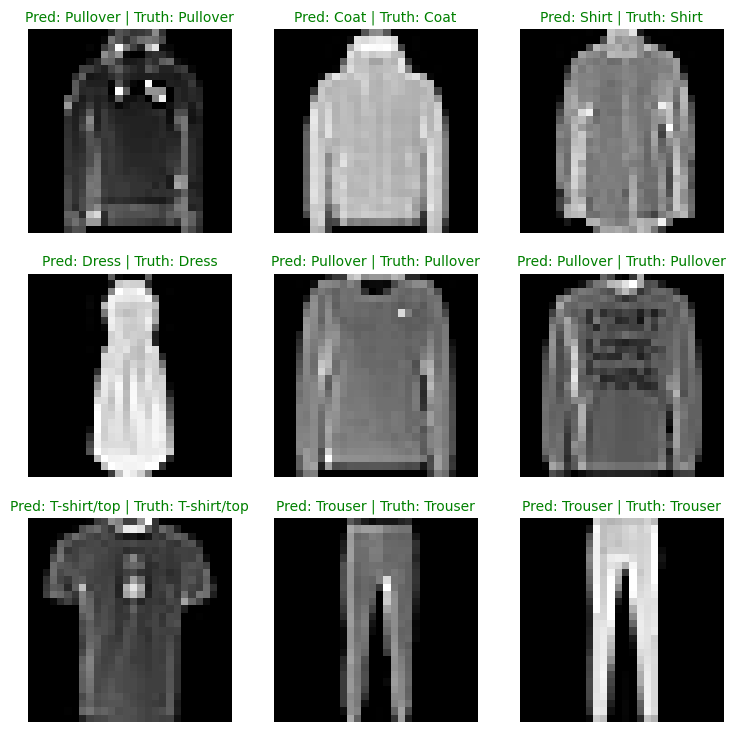

In [261]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

### Making confusion matrix for further prediction evaluation

In [262]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [263]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [264]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


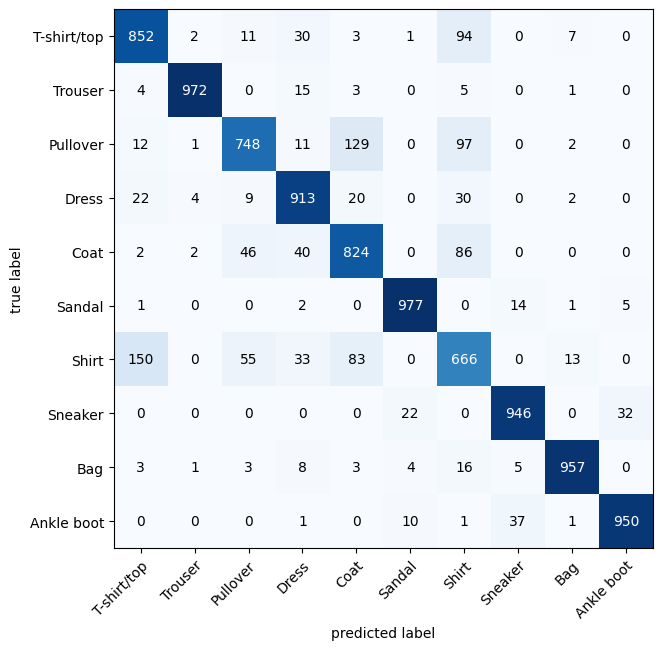

In [265]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

### Save and load best performing model

In [266]:
from pathlib import Path

# Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_2.pth


In [267]:
# Create a new instance of FashionMNISTModelV2 (the same class as our saved state_dict())
# Note: loading model will error if the shapes here aren't the same as the saved version
loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                    hidden_units=10, # try changing this to 128 and seeing what happens
                                    output_shape=10)

# Load in the saved state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send model to GPU
loaded_model_2 = loaded_model_2.to(device)

<ipython-input-267-01e1a5266d0e>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


In [269]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_laoder=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [271]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_laoder=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [274]:
mdoel_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [275]:
# Check to see if results are close to each other (if they are very far away, there may be an error)
torch.isclose(torch.tensor(mdoel_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08, # absolute tolerance
              rtol=0.0001) # relative tolerance

tensor(True)